# Case study: building footprints from four datasources (WFS + OSM)

Compare building polygon datasets around **Turin** using the **same study-area bbox**:

| GeoDataFrame | Provider | Protocol | Layer / filter | Product |
|---|---|---|---|---|
| `gdf_torino_edificato` | Comune di Torino (DBGT) | WFS 1.1 | `Edificato` | Municipal topographic buildings |
| `gdf_osm_buildings` | OpenStreetMap (community) | ohsome API | `building=*` | Crowdsourced building footprints |
| `gdf_bdtre_edifc` | Regione Piemonte (BDTRE) | WFS 1.1 | `edifc` | Edificio (official 2D footprint) |
| `gdf_bdtre_un_vol` | Regione Piemonte (BDTRE) | WFS 1.1 | `un_vol` | Unita volumetrica (3D volume block) |

### WFS vs WMS for BDTRE

- **WFS** returns **vector features** (polygons you can analyse in GeoPandas).
- **WMS** returns **map images** (PNG/JPEG tiles) for visualization only -- you cannot build a GeoDataFrame from WMS alone.

BDTRE is published as **both** on the Piemonte geoportal. This notebook uses **WFS** for vector comparison. A WMS preview cell is included later if you only want to check that the service is online.

### BDTRE `edifc` vs `un_vol` -- what is the difference?

| | **edifc** (Edificio) | **un_vol** (Unita volumetrica) |
|---|---|---|
| Geometry | 2D **building footprint** polygon (roof outline projected to ground) | **Volumetric unit** -- often a block representing built volume / massing |
| Semantics | Single building object as mapped in BDTRE | Aggregated or decomposed volume element (can group parts of a building) |
| Typical use | Cadastre-like footprint, area counts | 3D city models, height/volume analysis |
| Count in same area | Fewer, cleaner footprints | Often **more** or **different** shapes (splits, annexes) |
| Attributes | `edifc_ty`, `edifc_uso`, `edifc_stat`, ... | Volume-related BDTRE codes |

They come from the **same regional database** but are **different feature classes** -- not duplicates. Expect similar coverage but different polygon boundaries and attribute schemas.

Requirements: `geopandas`, `requests`, `shapely` (install in the next cell if missing).

In [3]:
# Install dependencies if needed (uncomment on first run)
# %pip install geopandas requests shapely pyproj

import json
from io import BytesIO
from pathlib import Path

import geopandas as gpd
import pandas as pd
import requests
from shapely.geometry import box, shape

pd.set_option("display.max_columns", 20)
print("geopandas", gpd.__version__)

geopandas 1.1.1


In [10]:
# Study area: small bbox in central Turin (EPSG:4326)
# Adjust MAX_FEATURES if downloads are slow or too large.

STUDY_AREA = {
    "name": "Turin centre",
    "bbox": (7.665, 45.065, 7.695, 45.085),  # xmin, ymin, xmax, ymax
    "crs": "EPSG:4326",
}

MAX_FEATURES = 5000       # Torino WFS tolerates large requests
BDTRE_MAX_FEATURES = 1000 # BDTRE WFS returns HTTP 400 above ~1000 features

study_polygon = box(*STUDY_AREA["bbox"])
print(STUDY_AREA)
print("BDTRE max features cap:", BDTRE_MAX_FEATURES)

{'name': 'Turin centre', 'bbox': (7.665, 45.065, 7.695, 45.085), 'crs': 'EPSG:4326'}
BDTRE max features cap: 1000


In [17]:
def wfs_get_geojson(
    base_url: str,
    layer: str,
    bbox: tuple[float, float, float, float],
    *,
    version: str = "1.1.0",
    count: int = MAX_FEATURES,
    output_format: str = "geojson",
    timeout: int = 120,
) -> dict:
    """Fetch a WFS GetFeature response as GeoJSON (dict).

    Note: BDTRE (MapServer) returns 0 features for WFS 2.0 + EPSG:4326 bbox.
    Use version 1.1.0 for reliable spatial filtering on that service.
    """
    params = {
        "service": "WFS",
        "version": version,
        "request": "GetFeature",
        "bbox": ",".join(str(v) for v in bbox),
        "srsName": "EPSG:4326",
        "outputFormat": output_format,
    }
    if version.startswith("2"):
        params["typeNames"] = layer
        params["count"] = count
    else:
        params["typeName"] = layer
        params["maxFeatures"] = count

    r = requests.get(base_url, params=params, timeout=timeout)
    r.raise_for_status()
    if r.text.lstrip().startswith("<"):
        raise ValueError(f"WFS returned XML instead of JSON for layer={layer}: {r.text[:300]}")
    return r.json()


def wfs_get_gml_url(
    base_url: str,
    layer: str,
    bbox: tuple[float, float, float, float],
    *,
    version: str = "1.1.0",
    max_features: int = MAX_FEATURES,
    output_format: str = "GML2",
) -> str:
    """Build a WFS GetFeature URL for GDAL/geopandas (GML output)."""
    bbox_str = ",".join(str(v) for v in bbox)
    return (
        f"{base_url}?service=WFS&version={version}&request=GetFeature"
        f"&typeName={layer}&bbox={bbox_str}&srsName=EPSG:4326"
        f"&maxFeatures={max_features}&outputFormat={output_format}"
    )


def geojson_to_gdf(fc: dict, source_name: str) -> gpd.GeoDataFrame:
    """Convert a GeoJSON FeatureCollection dict to a GeoDataFrame."""
    gdf = gpd.GeoDataFrame.from_features(fc.get("features", []), crs="EPSG:4326")
    gdf["source"] = source_name
    return gdf


def compare_gdf(name: str, gdf: gpd.GeoDataFrame) -> pd.Series:
    """Quick summary row for side-by-side comparison."""
    geom_types = gdf.geometry.geom_type.value_counts().to_dict() if len(gdf) else {}
    return pd.Series({
        "datasource": name,
        "features": len(gdf),
        "columns": len(gdf.columns),
        "crs": str(gdf.crs),
        "geometry_types": geom_types,
        "attribute_cols": [c for c in gdf.columns if c not in ("geometry", "source")][:8],
    })


def _osm_headers() -> dict:
    return {"User-Agent": "CIM-wizard-case-study/1.0 (research; contact: local)"}


def _fetch_osm_ohsome(bbox: tuple[float, float, float, float], timeout: int) -> gpd.GeoDataFrame:
    """Primary: ohsome API returns GeoJSON directly (stable, no Overpass 406 issues)."""
    xmin, ymin, xmax, ymax = bbox
    r = requests.get(
        "https://api.ohsome.org/v1/elements/geometry",
        params={
            "bboxes": f"{xmin},{ymin},{xmax},{ymax}",
            "types": "way,relation",
            "keys": "building",
            "properties": "tags",
        },
        headers=_osm_headers(),
        timeout=timeout,
    )
    r.raise_for_status()
    fc = r.json()
    gdf = gpd.GeoDataFrame.from_features(fc.get("features", []), crs="EPSG:4326")
    gdf["source"] = "OSM buildings"
    return gdf


def _fetch_osm_overpass(bbox: tuple[float, float, float, float], timeout: int) -> gpd.GeoDataFrame:
    """Fallback: Overpass API (needs User-Agent; some mirrors return HTTP 406 without it)."""
    xmin, ymin, xmax, ymax = bbox
    query = f"""
[out:json][timeout:90];
(
  way["building"]({ymin},{xmin},{ymax},{xmax});
);
out body;
>;
out skel qt;
"""
    mirrors = [
        "https://overpass-api.de/api/interpreter",
        "https://lz4.overpass-api.de/api/interpreter",
    ]
    headers = _osm_headers()
    last_err = None
    data = None
    for url in mirrors:
        for attempt in (
            lambda u=url: requests.post(u, data={"data": query}, headers=headers, timeout=timeout),
            lambda u=url: requests.post(
                u, data=query.encode("utf-8"),
                headers={**headers, "Content-Type": "text/plain; charset=utf-8"},
                timeout=timeout,
            ),
            lambda u=url: requests.get(u, params={"data": query}, headers=headers, timeout=timeout),
        ):
            try:
                r = attempt()
                r.raise_for_status()
                data = r.json()
                break
            except Exception as exc:
                last_err = exc
        if data is not None:
            break
    if data is None:
        raise RuntimeError(f"Overpass fallback failed: {last_err}")

    nodes = {el["id"]: (el["lon"], el["lat"]) for el in data["elements"] if el["type"] == "node"}
    features = []
    for el in data["elements"]:
        if el["type"] != "way" or "tags" not in el or "building" not in el["tags"]:
            continue
        coords = [nodes[n] for n in el.get("nodes", []) if n in nodes]
        if len(coords) < 3:
            continue
        features.append({
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [coords + [coords[0]]]},
            "properties": el["tags"],
        })

    gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
    gdf["source"] = "OSM buildings"
    return gdf


def fetch_osm_buildings(bbox: tuple[float, float, float, float], timeout: int = 120) -> gpd.GeoDataFrame:
    """Fetch OSM building polygons (ohsome API first, Overpass fallback)."""
    try:
        return _fetch_osm_ohsome(bbox, timeout)
    except Exception as ohsome_err:
        print(f"ohsome failed ({ohsome_err}), trying Overpass...")
        return _fetch_osm_overpass(bbox, timeout)


def fetch_bdtre_layer(
    layer: str,
    bbox: tuple[float, float, float, float],
    *,
    max_features: int = BDTRE_MAX_FEATURES,
) -> gpd.GeoDataFrame:
    """Fetch a BDTRE WFS layer with GeoJSON first, GML fallback."""
    base = "https://geoservices.csi.it/ms/wfs/taims/rp-01/taimswfs/bdtre_imm"
    try:
        fc = wfs_get_geojson(
            base, layer, bbox, version="1.1.0",
            count=max_features, output_format="geojson",
        )
        return geojson_to_gdf(fc, source_name=f"BDTRE {layer}")
    except Exception as geo_err:
        print(f"GeoJSON failed for {layer}: {geo_err}")
        print("Trying GML2 via geopandas...")
        url = wfs_get_gml_url(base, layer, bbox, version="1.1.0", max_features=max_features)
        gdf = gpd.read_file(url)
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)
        gdf["source"] = f"BDTRE {layer}"
        return gdf

## Datasource 1 -- Comune di Torino DBGT Edificato (WFS)

Municipal topographic building layer from **Comune di Torino**. This one is the most reliable WFS in the case study.

- WFS 1.1.0, GML2 output, read via geopandas/GDAL

In [12]:
TORINO_WFS = (
    "http://geomap.reteunitaria.piemonte.it/ws/siccms/coto-01/wfsg01/wfs_sicc140_edificato_dbgt"
)

torino_url = wfs_get_gml_url(
    TORINO_WFS,
    layer="Edificato",
    bbox=STUDY_AREA["bbox"],
    version="1.1.0",
    output_format="GML2",
)

gdf_torino_edificato = gpd.read_file(torino_url)
gdf_torino_edificato = gdf_torino_edificato.set_crs("EPSG:4326", allow_override=True)
gdf_torino_edificato["source"] = "Torino DBGT Edificato"

print(f"Fetched {len(gdf_torino_edificato)} features")
gdf_torino_edificato.head()

Fetched 4850 features


,gml_id,codice_intesa,gruppo,descrizione,categoria_uso,epoca_costruzione,numero_piani,altezza_edificio,valenza_storica,nome,qt_gronda,qt_suolo,transito,geometry,source
0,Edificato.260455,020106,EDIFICI MINORI (O DI PERTINENZA),basso fabbricato generico,None,non conosciuto,None,None,None,None,None,228.43,None,"POLYGON ((45.08445 7.68244, 45.08443 7.68249, ...",Torino DBGT Edificato
1,Edificato.163513,020106,EDIFICI MINORI (O DI PERTINENZA),basso fabbricato generico,None,non conosciuto,None,4.23,None,None,229.56,225.33,None,"POLYGON ((45.07913 7.69326, 45.07918 7.69321, ...",Torino DBGT Edificato
2,Edificato.127411,020106,EDIFICI MINORI (O DI PERTINENZA),"garage, box auto",None,non conosciuto,None,3.21,None,None,229.47,226.26,None,"POLYGON ((45.08234 7.69056, 45.08233 7.69055, ...",Torino DBGT Edificato
3,Edificato.260614,020106,EDIFICI MINORI (O DI PERTINENZA),basso fabbricato generico,None,non conosciuto,None,6.4,None,None,232.51,226.11,None,"POLYGON ((45.08147 7.68981, 45.08152 7.68978, ...",Torino DBGT Edificato
4,Edificato.34999,020106,EDIFICI MINORI (O DI PERTINENZA),basso fabbricato generico,None,1918 (al ..),None,None,None,None,None,241.13,None,"POLYGON ((45.07494 7.67864, 45.07494 7.67865, ...",Torino DBGT Edificato


## Datasource 2 -- OpenStreetMap buildings (ohsome API)

OSM is **not WFS**. This notebook uses the **[ohsome API](https://ohsome.org/)** (`api.ohsome.org`) which returns GeoJSON building geometries for a bbox. Overpass API is kept as fallback.

- Crowdsourced, global, frequently updated
- Good baseline to compare against official municipal/regional data

In [18]:
gdf_osm_buildings = fetch_osm_buildings(STUDY_AREA["bbox"])
print(f"Fetched {len(gdf_osm_buildings)} OSM building features")
gdf_osm_buildings.head()

Fetched 3758 OSM building features


,geometry,@osmId,@snapshotTimestamp,building,type,building:levels,heritage,roof:levels,roof:shape,name,...,artwork_type,length,width,display,support,visibility,changing_table,unisex,emergency,note
0,"POLYGON ((7.695 45.07064, 7.69496 45.07061, 7....",relation/2894588,2026-02-19T12:00:00Z,yes,multipolygon,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"POLYGON ((7.69127 45.06736, 7.69141 45.06727, ...",relation/4445604,2026-02-19T12:00:00Z,apartments,multipolygon,5,2,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"POLYGON ((7.69103 45.06711, 7.69089 45.06691, ...",relation/4445605,2026-02-19T12:00:00Z,apartments,multipolygon,6,NaN,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"POLYGON ((7.69363 45.06606, 7.69365 45.06605, ...",relation/5340782,2026-02-19T12:00:00Z,apartments,multipolygon,5,NaN,1,hipped,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GEOMETRYCOLLECTION (POLYGON ((7.69221 45.08054...,relation/10555169,2026-02-19T12:00:00Z,yes,building,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Datasource 3 -- BDTRE Edificio (`edifc`) via WFS

Regional **2D building footprints** from Regione Piemonte BDTRE.

- Endpoint: `https://geoservices.csi.it/ms/wfs/taims/rp-01/taimswfs/bdtre_imm`
- Do **not** use the old `geomap.reteunitaria.piemonte.it` URL for WFS (returns mapfile errors)
- Server rejects `maxFeatures > 1000` -- use `BDTRE_MAX_FEATURES`
- WMS sibling (visual only): `https://geoservices.csi.it/ms/wms/taims/rp-01/taimswms/bdtre_imm`

In [14]:
gdf_bdtre_edifc = fetch_bdtre_layer("edifc", STUDY_AREA["bbox"])
print(f"Fetched {len(gdf_bdtre_edifc)} features")
gdf_bdtre_edifc.head()

Fetched 956 features


,geometry,uuid,data_acq,data_agg,data_fin,ente_for,ente_prod,modo_prod,sc_acq,edifc_ty,edifc_uso,edifc_stat,edifc_mon,edifc_nome,edifc_idag,edifc_ided,source
0,"POLYGON ((7.68591 45.08106, 7.68588 45.08103, ...",52093623-3831-440c-bd96-27f855d6842a,2025-08-31 00:00:00,2025-08-31 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,industriale,costruito,0,,,,BDTRE edifc
1,"POLYGON ((7.66918 45.07574, 7.66891 45.07584, ...",23c0ed0c-c9e5-4217-a78e-4294446d6f58,2019-11-30 00:00:00,2019-11-30 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,residenziale e commerciale,costruito,0,,,,BDTRE edifc
2,"POLYGON ((7.66611 45.08322, 7.6662 45.08336, 7...",0b570889-2238-4f2e-ac49-bc7c942ac961,2019-11-30 00:00:00,2019-11-30 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,residenziale e commerciale,costruito,0,,,,BDTRE edifc
3,"POLYGON ((7.66775 45.07892, 7.66766 45.07885, ...",5378ddc7-201d-42d2-89d3-01e74f8343e5,2019-11-30 00:00:00,2019-11-30 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,residenziale e commerciale,costruito,0,,,,BDTRE edifc
4,"POLYGON ((7.67552 45.08258, 7.67554 45.08258, ...",74321239-9965-496d-a699-28aa17eac519,2019-11-30 00:00:00,2019-11-30 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,generica,residenziale e commerciale,costruito,0,,,,BDTRE edifc


## Datasource 4 -- BDTRE Unita volumetrica (`un_vol`) via WFS

Same BDTRE WFS endpoint, **different feature class**. See intro table for how `un_vol` differs from `edifc`:

- `edifc` = 2D roof/footprint outline of a building
- `un_vol` = volumetric unit used for 3D city modelling (may split/merge differently)

Expect similar geographic coverage but **different polygon shapes and counts**.

In [15]:
gdf_bdtre_un_vol = fetch_bdtre_layer("un_vol", STUDY_AREA["bbox"])
print(f"Fetched {len(gdf_bdtre_un_vol)} features")
gdf_bdtre_un_vol.head()

Fetched 959 features


,geometry,uuid,data_acq,data_agg,data_fin,ente_for,ente_prod,modo_prod,sc_acq,un_vol_av,un_vol_por,un_vol_qe,un_vol_ex,source
0,"POLYGON ((7.67485 45.07306, 7.67486 45.07308, ...",adb2dccb-0b57-4ffd-95ca-e114e3653a29,2019-11-30 00:00:00,2019-11-30 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,,al suolo,,,BDTRE un_vol
1,"POLYGON ((7.68748 45.07168, 7.68747 45.07168, ...",abdf028a-e888-47e7-8a43-8b6fec080110,2019-11-30 00:00:00,2019-11-30 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,REGIONE PIEMONTE,banche dati esterne - catasto,1:2000,,al suolo,,,BDTRE un_vol
2,"POLYGON ((7.66918 45.07574, 7.66891 45.07584, ...",7a277103-6a5e-4753-9e0c-5c71d34dca2c,2017-12-31 00:00:00,2017-12-31 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,ARPA PIEMONTE,"banche dati esterne - geometrie da catasto, al...",1:10000,18,al suolo,,altezza,BDTRE un_vol
3,"POLYGON ((7.66611 45.08322, 7.6662 45.08336, 7...",3b952b1e-410a-4ab3-94e5-19b878b92d6d,2017-12-31 00:00:00,2017-12-31 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,ARPA PIEMONTE,"banche dati esterne - geometrie da catasto, al...",1:10000,16,al suolo,,altezza,BDTRE un_vol
4,"POLYGON ((7.66775 45.07892, 7.66766 45.07885, ...",29363cf6-7b5e-4980-9246-613585ceb59e,2017-12-31 00:00:00,2017-12-31 00:00:00,9999-12-31 00:00:00,REGIONE PIEMONTE,ARPA PIEMONTE,"banche dati esterne - geometrie da catasto, al...",1:10000,18,al suolo,,altezza,BDTRE un_vol


## Optional -- BDTRE WMS preview (map image, not vectors)

WMS is useful to **verify the service is online** and see symbology. It does **not** replace WFS for GeoDataFrame analysis.

In [ ]:
from IPython.display import Image, display

BDTRE_WMS = "https://geoservices.csi.it/ms/wms/taims/rp-01/taimswms/bdtre_imm"
xmin, ymin, xmax, ymax = STUDY_AREA["bbox"]
# WMS 1.3.0 bbox order: miny,minx,maxy,maxx
wms_url = (
    f"{BDTRE_WMS}?service=WMS&version=1.3.0&request=GetMap"
    f"&layers=edifc&styles=&crs=EPSG:4326"
    f"&bbox={ymin},{xmin},{ymax},{xmax}"
    f"&width=800&height=600&format=image/png"
)
try:
    display(Image(url=wms_url))
except Exception as exc:
    print("WMS preview failed:", exc)
    print("URL:", wms_url)

## Compare the four GeoDataFrames

In [19]:
ALL_GDFS = {
    "Torino DBGT": gdf_torino_edificato,
    "OSM": gdf_osm_buildings,
    "BDTRE edifc": gdf_bdtre_edifc,
    "BDTRE un_vol": gdf_bdtre_un_vol,
}

summary = pd.DataFrame([compare_gdf(name, gdf) for name, gdf in ALL_GDFS.items()])
summary

,datasource,features,columns,crs,geometry_types,attribute_cols
0,Torino DBGT,4850,15,EPSG:4326,"{'Polygon': 4813, 'MultiPolygon': 37}","[gml_id, codice_intesa, gruppo, descrizione, c..."
1,OSM,3758,164,EPSG:4326,"{'Polygon': 3744, 'MultiPolygon': 10, 'Geometr...","[@osmId, @snapshotTimestamp, building, type, b..."
2,BDTRE edifc,956,17,EPSG:4326,{'Polygon': 956},"[uuid, data_acq, data_agg, data_fin, ente_for,..."
3,BDTRE un_vol,959,14,EPSG:4326,{'Polygon': 959},"[uuid, data_acq, data_agg, data_fin, ente_for,..."


In [20]:
# Attribute schema comparison (column names only)
for label, gdf in ALL_GDFS.items():
    cols = [c for c in gdf.columns if c not in ("geometry", "source")]
    print(f"{label}: {len(cols)} attrs -> {cols[:12]}{'...' if len(cols)>12 else ''}")

Torino DBGT: 13 attrs -> ['gml_id', 'codice_intesa', 'gruppo', 'descrizione', 'categoria_uso', 'epoca_costruzione', 'numero_piani', 'altezza_edificio', 'valenza_storica', 'nome', 'qt_gronda', 'qt_suolo']...
OSM: 162 attrs -> ['@osmId', '@snapshotTimestamp', 'building', 'type', 'building:levels', 'heritage', 'roof:levels', 'roof:shape', 'name', 'wikidata', 'access', 'architect']...
BDTRE edifc: 15 attrs -> ['uuid', 'data_acq', 'data_agg', 'data_fin', 'ente_for', 'ente_prod', 'modo_prod', 'sc_acq', 'edifc_ty', 'edifc_uso', 'edifc_stat', 'edifc_mon']...
BDTRE un_vol: 12 attrs -> ['uuid', 'data_acq', 'data_agg', 'data_fin', 'ente_for', 'ente_prod', 'modo_prod', 'sc_acq', 'un_vol_av', 'un_vol_por', 'un_vol_qe', 'un_vol_ex']


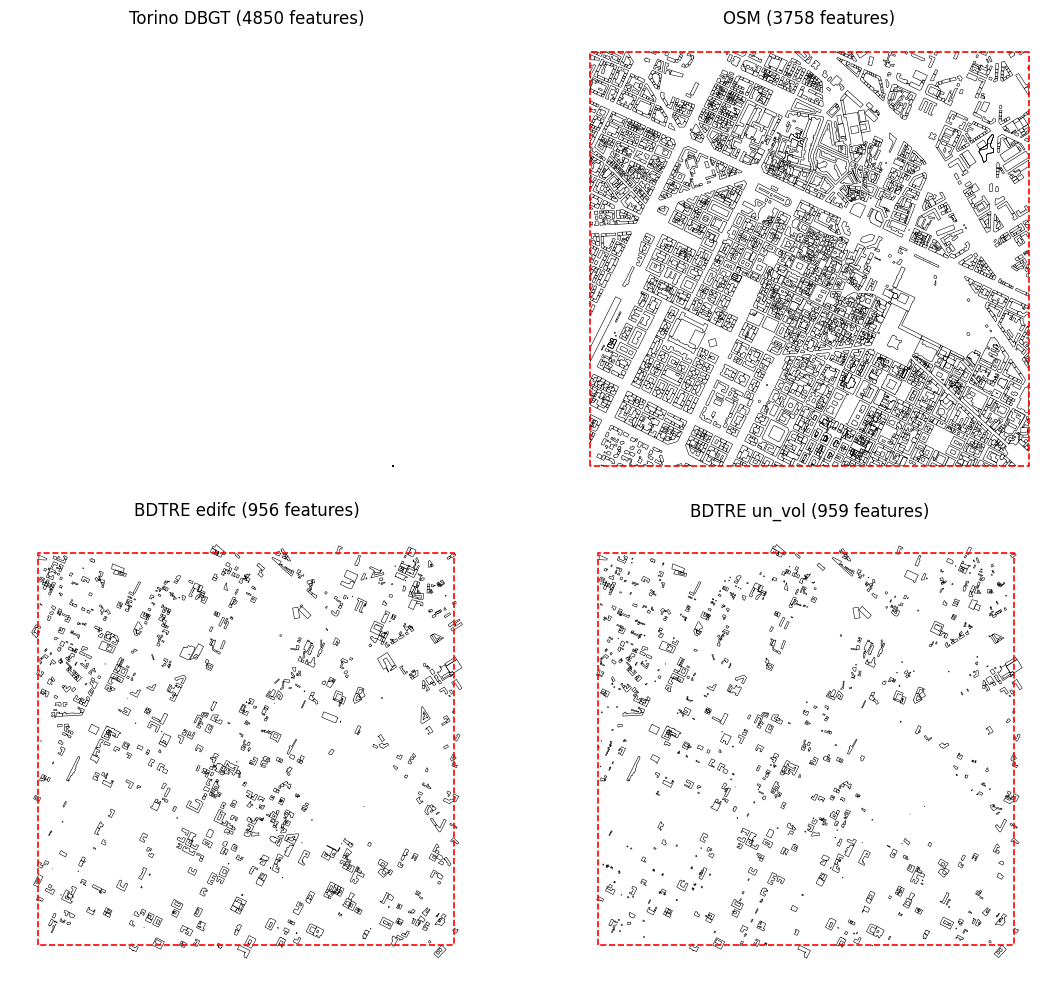

In [21]:
# Quick map overlay (requires matplotlib)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (title, gdf) in zip(axes, ALL_GDFS.items()):
    gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.4)
    gpd.GeoSeries([study_polygon], crs="EPSG:4326").plot(
        ax=ax, facecolor="none", edgecolor="red", linewidth=1.2, linestyle="--"
    )
    ax.set_title(f"{title} ({len(gdf)} features)")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [22]:
# Optional: save locally for offline comparison / warehouse ingest tests
OUT = Path("case_study_output")
OUT.mkdir(exist_ok=True)

gdf_torino_edificato.to_file(OUT / "torino_edificato.geojson", driver="GeoJSON")
gdf_osm_buildings.to_file(OUT / "osm_buildings.geojson", driver="GeoJSON")
gdf_bdtre_edifc.to_file(OUT / "bdtre_edifc.geojson", driver="GeoJSON")
gdf_bdtre_un_vol.to_file(OUT / "bdtre_un_vol.geojson", driver="GeoJSON")

print("Saved to", OUT.resolve())

Saved to /mnt/Data_HDD/00products/CIM_wizard/datalake/case_study_output


## Ingest saved GeoJSON into the PostGIS warehouse (FastAPI)

Load the files from `case_study_output/` and POST each one to the running API (`http://localhost:8008`).

Requires `bash datawarehouse.sh` to be running in `datalake/api/`.

In [ ]:
import uuid
from shapely.geometry import mapping

OUT = Path("case_study_output")

SAVED_FILES = {
    "torino_edificato": OUT / "torino_edificato.geojson",
    "osm_buildings":    OUT / "osm_buildings.geojson",
    "bdtre_edifc":      OUT / "bdtre_edifc.geojson",
    "bdtre_un_vol":     OUT / "bdtre_un_vol.geojson",
}

loaded_gdfs: dict[str, gpd.GeoDataFrame] = {}
for name, path in SAVED_FILES.items():
    if not path.exists():
        print(f"SKIP (missing): {path}")
        continue
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    else:
        gdf = gdf.to_crs("EPSG:4326")
    loaded_gdfs[name] = gdf
    print(f"{name}: {len(gdf)} features  |  {path.name}")

print(f"\nLoaded {len(loaded_gdfs)} datasource(s) from {OUT.resolve()}")

In [ ]:
API_BASE = "http://localhost:8008"
MAX_INGEST_FEATURES = None  # set e.g. 500 for a quick test; None = ingest all rows

DATASOURCE_META = {
    "torino_edificato": {
        "name": "Case study - Torino DBGT Edificato",
        "description": "Municipal building footprints from Comune di Torino WFS",
        "tags": ["case-study", "buildings", "torino", "dbgt", "wfs"],
        "source_type": "ogc",
        "ogc_url": "http://geomap.reteunitaria.piemonte.it/ws/siccms/coto-01/wfsg01/wfs_sicc140_edificato_dbgt",
        "ogc_type": "WFS",
        "format": "WFS/GML",
    },
    "osm_buildings": {
        "name": "Case study - OSM buildings",
        "description": "OpenStreetMap building footprints via ohsome API",
        "tags": ["case-study", "buildings", "osm", "crowdsourced"],
        "source_type": "api",
        "ogc_url": "https://api.ohsome.org/v1/elements/geometry",
        "ogc_type": None,
        "format": "GeoJSON",
    },
    "bdtre_edifc": {
        "name": "Case study - BDTRE Edificio",
        "description": "Regional BDTRE building footprints (edifc)",
        "tags": ["case-study", "buildings", "bdtre", "piemonte", "wfs"],
        "source_type": "ogc",
        "ogc_url": "https://geoservices.csi.it/ms/wfs/taims/rp-01/taimswfs/bdtre_imm",
        "ogc_type": "WFS",
        "format": "WFS/GeoJSON",
    },
    "bdtre_un_vol": {
        "name": "Case study - BDTRE Unita volumetrica",
        "description": "Regional BDTRE volumetric units (un_vol)",
        "tags": ["case-study", "buildings", "bdtre", "piemonte", "wfs", "3d"],
        "source_type": "ogc",
        "ogc_url": "https://geoservices.csi.it/ms/wfs/taims/rp-01/taimswfs/bdtre_imm",
        "ogc_type": "WFS",
        "format": "WFS/GeoJSON",
    },
}


def _json_safe(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return None
    if hasattr(val, "isoformat"):
        return val.isoformat()
    if hasattr(val, "item"):
        try:
            return val.item()
        except Exception:
            pass
    return val


def gdf_footprint(gdf: gpd.GeoDataFrame) -> dict:
  xmin, ymin, xmax, ymax = gdf.total_bounds
  return mapping(box(xmin, ymin, xmax, ymax))


def gdf_to_features(gdf: gpd.GeoDataFrame, limit: int | None = None) -> list[dict]:
    rows = []
    subset = gdf.head(limit) if limit else gdf
    for _, row in subset.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        attrs = {
            k: _json_safe(v)
            for k, v in row.items()
            if k != "geometry"
        }
        rows.append({
            "geometry": mapping(geom),
            "attributes": attrs,
        })
    return rows


def build_payload(key: str, gdf: gpd.GeoDataFrame) -> dict:
    meta = DATASOURCE_META[key]
    geom_types = gdf.geometry.geom_type.value_counts()
    primary_geom = geom_types.index[0] if len(geom_types) else "Polygon"

    manifest = {
        "ingest_manifest_version": "1.0",
        "manifest_id": str(uuid.uuid4()),
        "datasource_class": {
            "is_spatial": True,
            "data_class": "vector",
            "format": meta["format"],
            "source_type": meta["source_type"],
        },
        "source": {
            "type": meta["source_type"],
            "filename": f"{key}.geojson",
            "format": meta["format"],
            "ogc_url": meta.get("ogc_url"),
            "ogc_type": meta.get("ogc_type"),
        },
        "profile": {
            "detected_crs": "EPSG:4326",
            "geom_type": primary_geom,
            "feature_count": len(gdf),
        },
        "registry": {
            "name": meta["name"],
            "description": meta["description"],
            "tags": meta["tags"],
            "crs": "EPSG:4326",
        },
        "warehouse_mapping": {
            "pk": {"policy": "uuid_per_row"},
            "fk": [{"value": None, "note": "dataset_id auto-assigned at load time"}],
            "spatial": {"target_crs": "EPSG:4326", "geom_column": "__geometry__"},
            "non_spatial": {"strategy": "jsonb", "target_column": "attributes"},
        },
    }

    return {
        "registry": {
            "name": meta["name"],
            "description": meta["description"],
            "tags": meta["tags"],
            "crs": "EPSG:4326",
            "location": "Turin, Piedmont",
        },
        "source": manifest["source"],
        "spatial_footprint": gdf_footprint(gdf),
        "datasource_class": manifest["datasource_class"],
        "manifest": manifest,
        "features": gdf_to_features(gdf, limit=MAX_INGEST_FEATURES),
    }


# health check
hc = requests.get(f"{API_BASE}/health", timeout=5)
print("API health:", hc.json())

ingest_results = []
for key, gdf in loaded_gdfs.items():
    payload = build_payload(key, gdf)
    n_feat = len(payload["features"])
    print(f"POST {key} ({n_feat} features)...", end=" ")
    resp = requests.post(
        f"{API_BASE}/api/v1/datasources",
        json=payload,
        timeout=600,
    )
    if resp.ok:
        body = resp.json()
        print(f"OK  dataset_id={body.get('dataset_id')}  ingested={body.get('feature_count')}")
        ingest_results.append({"key": key, **body})
    else:
        print(f"FAILED {resp.status_code}: {resp.text[:200]}")

pd.DataFrame(ingest_results)

In [1]:
import uuid
from shapely.geometry import mapping

In [4]:

OUT = Path("case_study_output")

SAVED_FILES = {
    # "torino_edificato": OUT / "torino_edificato.geojson",
    # "osm_buildings":    OUT / "osm_buildings.geojson",
    # "bdtre_edifc":      OUT / "bdtre_edifc.geojson",
    "bdtre_un_vol":     OUT / "bdtre_un_vol.geojson",
}

loaded_gdfs: dict[str, gpd.GeoDataFrame] = {}
for name, path in SAVED_FILES.items():
    if not path.exists():
        print(f"SKIP (missing): {path}")
        continue
    gdf = gpd.read_file(path)
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")
    else:
        gdf = gdf.to_crs("EPSG:4326")
    loaded_gdfs[name] = gdf
    print(f"{name}: {len(gdf)} features  |  {path.name}")

print(f"\nLoaded {len(loaded_gdfs)} datasource(s) from {OUT.resolve()}")

bdtre_un_vol: 959 features  |  bdtre_un_vol.geojson

Loaded 1 datasource(s) from /mnt/Data_HDD/00products/CIM_wizard/datalake/case_study_output


In [6]:
API_BASE = "http://localhost:8008"
MAX_INGEST_FEATURES = None  # set e.g. 500 for a quick test; None = ingest all rows

DATASOURCE_META = {

    "bdtre_un_vol": {
        "name": "Case study - BDTRE Unita volumetrica",
        "description": "Regional BDTRE volumetric units (un_vol)",
        "tags": ["case-study", "buildings", "bdtre", "piemonte", "wfs", "3d"],
        "source_type": "ogc",
        "ogc_url": "https://geoservices.csi.it/ms/wfs/taims/rp-01/taimswfs/bdtre_imm",
        "ogc_type": "WFS",
        "format": "WFS/GeoJSON",
    },
}


def _json_safe(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return None
    if hasattr(val, "isoformat"):
        return val.isoformat()
    if hasattr(val, "item"):
        try:
            return val.item()
        except Exception:
            pass
    return val


def gdf_footprint(gdf: gpd.GeoDataFrame) -> dict:
  xmin, ymin, xmax, ymax = gdf.total_bounds
  return mapping(box(xmin, ymin, xmax, ymax))


def gdf_to_features(gdf: gpd.GeoDataFrame, limit: int | None = None) -> list[dict]:
    rows = []
    subset = gdf.head(limit) if limit else gdf
    for _, row in subset.iterrows():
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        attrs = {
            k: _json_safe(v)
            for k, v in row.items()
            if k != "geometry"
        }
        rows.append({
            "geometry": mapping(geom),
            "attributes": attrs,
        })
    return rows


def build_payload(key: str, gdf: gpd.GeoDataFrame) -> dict:
    meta = DATASOURCE_META[key]
    geom_types = gdf.geometry.geom_type.value_counts()
    primary_geom = geom_types.index[0] if len(geom_types) else "Polygon"

    manifest = {
        "ingest_manifest_version": "1.0",
        "manifest_id": str(uuid.uuid4()),
        "datasource_class": {
            "is_spatial": True,
            "data_class": "vector",
            "format": meta["format"],
            "source_type": meta["source_type"],
        },
        "source": {
            "type": meta["source_type"],
            "filename": f"{key}.geojson",
            "format": meta["format"],
            "ogc_url": meta.get("ogc_url"),
            "ogc_type": meta.get("ogc_type"),
        },
        "profile": {
            "detected_crs": "EPSG:4326",
            "geom_type": primary_geom,
            "feature_count": len(gdf),
        },
        "registry": {
            "name": meta["name"],
            "description": meta["description"],
            "tags": meta["tags"],
            "crs": "EPSG:4326",
        },
        "warehouse_mapping": {
            "pk": {"policy": "uuid_per_row"},
            "fk": [{"value": None, "note": "dataset_id auto-assigned at load time"}],
            "spatial": {"target_crs": "EPSG:4326", "geom_column": "__geometry__"},
            "non_spatial": {"strategy": "jsonb", "target_column": "attributes"},
        },
    }

    return {
        "registry": {
            "name": meta["name"],
            "description": meta["description"],
            "tags": meta["tags"],
            "crs": "EPSG:4326",
            "location": "Turin, Piedmont",
        },
        "source": manifest["source"],
        "spatial_footprint": gdf_footprint(gdf),
        "datasource_class": manifest["datasource_class"],
        "manifest": manifest,
        "features": gdf_to_features(gdf, limit=MAX_INGEST_FEATURES),
    }

In [7]:

# health check
hc = requests.get(f"{API_BASE}/health", timeout=5)
print("API health:", hc.json())

ingest_results = []
for key, gdf in loaded_gdfs.items():
    payload = build_payload(key, gdf)
    n_feat = len(payload["features"])
    print(f"POST {key} ({n_feat} features)...", end=" ")
    resp = requests.post(
        f"{API_BASE}/api/v1/datasources",
        json=payload,
        timeout=600,
    )
    if resp.ok:
        body = resp.json()
        print(f"OK  dataset_id={body.get('dataset_id')}  ingested={body.get('feature_count')}")
        ingest_results.append({"key": key, **body})
    else:
        print(f"FAILED {resp.status_code}: {resp.text[:200]}")

pd.DataFrame(ingest_results)

API health: {'status': 'ok', 'db': 'connected'}
POST bdtre_un_vol (959 features)... OK  dataset_id=1649aee9-88a2-4e93-9559-a2597b862038  ingested=959


,key,dataset_id,manifest_id,feature_count
0,bdtre_un_vol,1649aee9-88a2-4e93-9559-a2597b862038,ca279329-3408-4464-99a9-e1919dd45b07,959


## Ingest to remote server via SSH tunnel

Forward the Data Warehouse API on **eclabuser@130.192.238.11:8008** to your laptop, then POST through the tunnel.

**Prerequisites on server:** `./run-datawarehouse.sh up` (API listening on port 8008).

**Auth options (pick one):**
- SSH key already configured for `eclabuser@130.192.238.11` (recommended)
- Or: `export SSH_PASSWORD='...'` and install `sshpass` (`sudo apt install sshpass`)

Local tunnel port defaults to **18008** so it does not clash with a local API on 8008.

In [8]:
import os
import shutil
import subprocess
import time

REMOTE_USER = "eclabuser"
REMOTE_HOST = "130.192.238.11"
REMOTE_API_PORT = 8008
LOCAL_TUNNEL_PORT = 18008

# Stop a previous tunnel from an earlier notebook run
if "ssh_tunnel_proc" in globals() and ssh_tunnel_proc.poll() is None:
    ssh_tunnel_proc.terminate()
    try:
        ssh_tunnel_proc.wait(timeout=5)
    except subprocess.TimeoutExpired:
        ssh_tunnel_proc.kill()
    print("Stopped previous SSH tunnel.")

ssh_cmd = [
    "ssh",
    "-N",
    "-L", f"{LOCAL_TUNNEL_PORT}:127.0.0.1:{REMOTE_API_PORT}",
    "-o", "StrictHostKeyChecking=no",
    "-o", "ServerAliveInterval=60",
    f"{REMOTE_USER}@{REMOTE_HOST}",
]

ssh_password = os.getenv("SSH_PASSWORD", "Cl0udThr332021!")
if ssh_password:
    if not shutil.which("sshpass"):
        raise RuntimeError("SSH_PASSWORD is set but sshpass is not installed (sudo apt install sshpass)")
    ssh_cmd = ["sshpass", "-p", ssh_password, *ssh_cmd]
else:
    print("No SSH_PASSWORD set — using your SSH key / agent.")

ssh_tunnel_proc = subprocess.Popen(
    ssh_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)
time.sleep(2)

if ssh_tunnel_proc.poll() is not None:
    err = ssh_tunnel_proc.stderr.read().decode("utf-8", errors="replace")
    raise RuntimeError(f"SSH tunnel failed to start:\n{err}")

REMOTE_API_BASE = f"http://127.0.0.1:{LOCAL_TUNNEL_PORT}"
hc = requests.get(f"{REMOTE_API_BASE}/health", timeout=10)
print(f"Tunnel OK: localhost:{LOCAL_TUNNEL_PORT} -> {REMOTE_HOST}:{REMOTE_API_PORT}")
print("Remote API health:", hc.json())

Tunnel OK: localhost:18008 -> 130.192.238.11:8008
Remote API health: {'status': 'ok', 'db': 'connected'}


In [9]:
# POST saved GeoJSON datasources to the REMOTE warehouse through the SSH tunnel

if "loaded_gdfs" not in globals() or not loaded_gdfs:
    raise RuntimeError("Run the 'load geojson' cell first (or re-run case_study_output loader).")

if "REMOTE_API_BASE" not in globals():
    raise RuntimeError("Run the SSH tunnel cell first.")

if ssh_tunnel_proc.poll() is not None:
    raise RuntimeError("SSH tunnel is not running. Re-run the tunnel cell.")

remote_ingest_results = []
for key, gdf in loaded_gdfs.items():
    payload = build_payload(key, gdf)
    n_feat = len(payload["features"])
    print(f"POST remote {key} ({n_feat} features)...", end=" ")
    resp = requests.post(
        f"{REMOTE_API_BASE}/api/v1/datasources",
        json=payload,
        timeout=600,
    )
    if resp.ok:
        body = resp.json()
        print(f"OK  dataset_id={body.get('dataset_id')}  ingested={body.get('feature_count')}")
        remote_ingest_results.append({"key": key, "server": REMOTE_HOST, **body})
    else:
        print(f"FAILED {resp.status_code}: {resp.text[:200]}")

pd.DataFrame(remote_ingest_results)

POST remote bdtre_un_vol (959 features)... OK  dataset_id=6257cbc1-1d92-499a-9bfe-6f43fc082209  ingested=959


,key,server,dataset_id,manifest_id,feature_count
0,bdtre_un_vol,130.192.238.11,6257cbc1-1d92-499a-9bfe-6f43fc082209,f9fe87d7-7c7e-4911-a317-6c4edfd27b63,959
